# NanowireML — Full Pipeline

**Reproducing and extending Raya et al. 2025** — sequence-only ML classification of microbial nanowire proteins.

**Research narrative:**
- **Phase 2 (primary)**: ESM-2 protein language model embeddings → near-perfect AUC, best-in-class calibration (ECE ≈ 0.0004)
- **Phase 3 (baseline)**: iFeature descriptors → reproduces Raya et al. 2025 Table 2
- **Phase 4**: Statistical comparison with aligned 5-fold CV + McNemar's test
- **Phase 5**: Feature ablation study
- **Phase 6**: Autoresearch loop

**Requirements:**
- T4 GPU runtime (Runtime → Change runtime type → T4 GPU)
- `GITHUB_PAT` set in Colab Secrets (left sidebar → key icon) for auto-push
- Works with VS Code + Google Colab extension (no browser dialogs needed)

**Usage:** Runtime → Run all  — runs completely unattended.

## Setup

In [56]:
# ── Environment detection + working directory ─────────────────────────────────
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.chdir('/content')
    !git clone https://github.com/moneet-dev/nanowire-ml.git 2>/dev/null || (cd nanowire-ml && git pull)
    os.chdir('/content/nanowire-ml')
elif os.path.basename(os.getcwd()).lower() == 'notebooks':
    os.chdir('..')

print(f'Working directory: {os.getcwd()}')

# ── Dependencies ──────────────────────────────────────────────────────────────
!pip install -q scikit-learn xgboost biopython shap matplotlib seaborn scipy 2>/dev/null
!pip install -q fair-esm 2>/dev/null
!pip install -q umap-learn 2>/dev/null

# iFeatureOmegaCLI: Python 3.14 workaround — install without deps, add networkx + rdkit separately
!pip install -q --no-deps iFeatureOmegaCLI
!pip install -q networkx rdkit 2>/dev/null

# ── Check GPU ─────────────────────────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}  ({props.total_memory / 1e9:.1f} GB VRAM)')
    !nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader
else:
    print('WARNING: No GPU detected. ESM-2 embedding will run on CPU (slower).')

print('\n=== Setup complete ===')

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.15 KiB | 1.07 MiB/s, done.
From https://github.com/moneet-dev/nanowire-ml
   e7ebdef..45cafce  main       -> origin/main
Updating e7ebdef..45cafce
Fast-forward
 notebooks/nanowire_ml_full_pipeline.ipynb | 371 +++++++++++++++---------------
 1 file changed, 188 insertions(+), 183 deletions(-)
Working directory: /content/nanowire-ml
GPU: Tesla T4  (15.6 GB VRAM)
Tesla T4, 15360 MiB, 580.82.07

=== Setup complete ===


In [57]:
# ── GitHub auto-push helper ───────────────────────────────────────────────────
# On Colab: add GITHUB_PAT to Colab Secrets (left sidebar → key icon).
# Locally:  pushes are skipped automatically.

import os, subprocess

REPO_DIR        = os.getcwd()   # already set to repo root by setup-cell
GITHUB_REMOTE   = 'https://github.com/moneet-dev/nanowire-ml.git'
ENABLE_AUTOPUSH = IN_COLAB      # True on Colab, False locally


def _get_pat() -> str:
    try:
        from google.colab import userdata
        token = userdata.get('GITHUB_PAT')
        if token:
            return token
    except Exception:
        pass
    return os.environ.get('GITHUB_PAT', '')


def auto_push(message: str, paths: list | None = None) -> bool:
    """Stage paths, commit, and push to GitHub. Clears PAT from remote URL immediately."""
    if not ENABLE_AUTOPUSH:
        return False
    token = _get_pat()
    if not token:
        print('  [push] skipped — add GITHUB_PAT to Colab Secrets (left sidebar key icon)')
        return False

    paths = paths or ['results/metrics/', 'scripts/', 'src/', 'notebooks/']

    try:
        subprocess.run(['git', 'config', 'user.email', 'devadigamoneet@gmail.com'],
                       cwd=REPO_DIR, capture_output=True)
        subprocess.run(['git', 'config', 'user.name', 'moneet-dev'],
                       cwd=REPO_DIR, capture_output=True)
        subprocess.run(['git', 'remote', 'set-url', 'origin',
                        f'https://{token}@github.com/moneet-dev/nanowire-ml.git'],
                       cwd=REPO_DIR, capture_output=True)

        for p in paths:
            subprocess.run(['git', 'add', p], cwd=REPO_DIR, capture_output=True)

        status = subprocess.run(['git', 'status', '--porcelain'],
                                capture_output=True, text=True, cwd=REPO_DIR)
        if not status.stdout.strip():
            print('  [push] nothing new to commit')
            subprocess.run(['git', 'remote', 'set-url', 'origin', GITHUB_REMOTE],
                           cwd=REPO_DIR, capture_output=True)
            return True

        subprocess.run(['git', 'commit', '-m', message],
                       cwd=REPO_DIR, capture_output=True)

        result = subprocess.run(['git', 'push', 'origin', 'main'],
                                capture_output=True, text=True, cwd=REPO_DIR)

        subprocess.run(['git', 'remote', 'set-url', 'origin', GITHUB_REMOTE],
                       cwd=REPO_DIR, capture_output=True)

        if result.returncode == 0:
            print(f'  [push] ✓  {message}')
            return True
        else:
            print(f'  [push] failed: {result.stderr[:400]}')
            return False
    except Exception as exc:
        subprocess.run(['git', 'remote', 'set-url', 'origin', GITHUB_REMOTE],
                       cwd=REPO_DIR, capture_output=True)
        print(f'  [push] error: {exc}')
        return False


print(f'auto_push() ready  (ENABLE_AUTOPUSH={ENABLE_AUTOPUSH})')

auto_push() ready  (ENABLE_AUTOPUSH=True)


In [58]:
# ── Google Drive mount (Colab only — skipped for local runs) ──────────────────
# Set USE_DRIVE = True when running on Google Colab to cache large embeddings
# across sessions. Keep False for local runs to use data/features/ directly.

import os

USE_DRIVE = False

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        feat_dir = '/content/drive/MyDrive/nanowire-ml/features'
        os.makedirs(feat_dir, exist_ok=True)

        local_feat = 'data/features'
        if os.path.islink(local_feat):
            os.unlink(local_feat)
        elif os.path.isdir(local_feat):
            import shutil; shutil.rmtree(local_feat)
        os.symlink(feat_dir, local_feat)
        print(f'Drive mounted.  Features dir -> {feat_dir}')
    except Exception as e:
        print(f'Drive mount failed ({e}).\nUsing local /content storage.')
        os.makedirs('data/features', exist_ok=True)
else:
    os.makedirs('data/features', exist_ok=True)
    print('Drive skipped. Using local data/features/ directory.')

Drive skipped. Using local data/features/ directory.


---
## Phase 1 — Data Preparation

Downloads and processes the Raya et al. 2025 dataset:
- Non-redundant (NR): 847 nanowire + 817 RecA = **1,664 sequences**
- Redundant: 998 + 999 = **1,997 sequences**

In [59]:
!python scripts/01_data_prep.py

Phase 1 - data preparation complete

  non-redundant : data/raw/merged.fasta, data/raw/labels.csv
  redundant     : data/raw/merged_redundant.fasta, data/raw/labels_redundant.csv
  sanity CSV    : results/metrics/data_sanity.csv

  n_total                           : 1664
  n_positive                        : 847
  n_negative                        : 817
  n_orphan_headers_repaired         : 1
  n_duplicate_sequences_dropped     : 333
  n_unique_sequences                : 1664
  len_positive_min                  : 40
  len_positive_median               : 135.0
  len_positive_max                  : 768
  len_positive_mean                 : 182.8
  aromatic_frac_positive_mean       : 0.0776
  len_negative_min                  : 72
  len_negative_median               : 344.0
  len_negative_max                  : 2054
  len_negative_mean                 : 353.4
  aromatic_frac_negative_mean       : 0.0551
  n_seqs_with_noncanonical_residues : 8
  redundant_n_total                 : 1997
  

In [60]:
import pandas as pd
from IPython.display import display

if __import__('os').path.exists('results/metrics/data_sanity.csv'):
    display(pd.read_csv('results/metrics/data_sanity.csv'))

auto_push('results: Phase 1 data preparation', ['results/metrics/data_sanity.csv'])

,metric,value
0,n_total,1664.0000
1,n_positive,847.0000
2,n_negative,817.0000
3,n_orphan_headers_repaired,1.0000
4,n_duplicate_sequences_dropped,333.0000
5,n_unique_sequences,1664.0000
6,len_positive_min,40.0000
7,len_positive_median,135.0000
8,len_positive_max,768.0000
9,len_positive_mean,182.8000


  [push] skipped — add GITHUB_PAT to Colab Secrets (left sidebar key icon)


False

---
## Phase 2 — ESM-2 Embeddings (PRIMARY)

Generates 1,280-dim mean-pooled ESM-2 embeddings (esm2_t33_650M_UR50D).

**Novel contributions:**
1. 5-fold stratified CV (rigorous, aligned with ablation study)
2. Layer-wise probing — finds which transformer layer best captures nanowire signal
3. UMAP visualization — confirms class separation in embedding space
4. OOF predictions saved for McNemar's statistical test in Phase 4

> **Runtime:** ~3 min embedding + ~4 min CV battery + ~1 min layer probing + ~3 min UMAP = **~11 min on T4**

In [61]:
!python -u scripts/04b_esm2_pipeline.py nr

Generating ESM-2 embeddings for variant='nr' ...
Loading ESM-2 model (esm2_t33_650M_UR50D) on cuda...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
  4/1664 [2s, ETA 881s]
  104/1664 [18s, ETA 271s]
  204/1664 [28s, ETA 198s]
  304/1664 [42s, ETA 189s]
  404/1664 [52s, ETA 163s]
  504/1664 [62s, ETA 143s]
  604/1664 [72s, ETA 126s]
  704/1664 [82s, ETA 112s]
  804/1664 [94s, ETA 101s]
  904/1664 [125s, ETA 105s]
  1004/1664 [172s, ETA 113s]
  1104/1664 [200s, ETA 101s]
  1204/1664 [219s, ETA 84s]
  1304/1664 [238s, ETA 66s]
  1404/1664 [259s, ETA 48s]
  1504/1664 [283s, ETA 30s]
  1604/1664 [306s, ETA 11s]
  saved esm2_embeddings.npy (1664, 1280)  +  esm2_layer_embs.npz (33 layers)  [332s]

ESM-2: X=(16

=== ESM-2 Classifier Battery (5-Fold CV) ===


,model,n_features,accuracy,roc_auc,roc_auc_ci,pr_auc,pr_auc_ci,ece,seconds
0,LR,1280,1.0000,1.0000,"[1.0000, 1.0000]",1.0000,"[1.0000, 1.0000]",0.0002,174.8
1,RF,1280,1.0000,1.0000,"[1.0000, 1.0000]",1.0000,"[1.0000, 1.0000]",0.0191,19.4
2,XGBoost,1280,0.9982,1.0000,"[0.9999, 1.0000]",1.0000,"[0.9999, 1.0000]",0.0023,34.6
3,XGB+Isotonic,1280,0.9970,0.9994,"[0.9981, 1.0000]",0.9988,"[0.9963, 1.0000]",0.0021,63.7
4,Stacking,1280,0.9988,1.0000,"[1.0000, 1.0000]",1.0000,"[1.0000, 1.0000]",0.0083,85.9



=== ESM-2 Layer Probing ===


,layer,roc_auc,roc_auc_ci_low,roc_auc_ci_high,pr_auc,pr_auc_ci_low,pr_auc_ci_high,ece
0,1,0.9999,0.9997,1.0,0.9999,0.9997,1.0,0.0035
1,2,0.9999,0.9999,1.0,0.9999,0.9999,1.0,0.0026
2,3,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0015
3,4,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0014
4,5,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0019
5,6,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0014
6,7,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0007
7,8,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0005
8,9,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0007
9,10,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.0007



--- esm2_umap.png ---


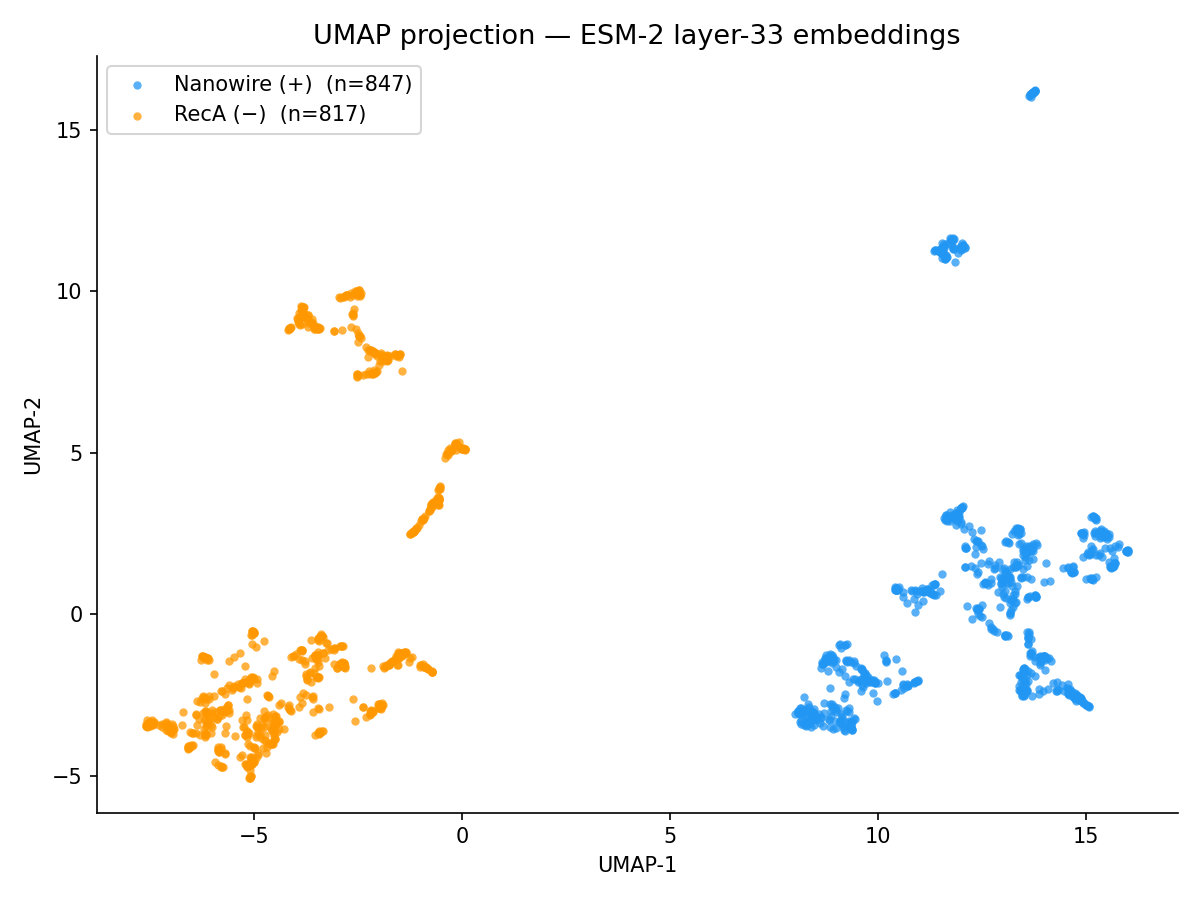


--- esm2_layer_probing.png ---


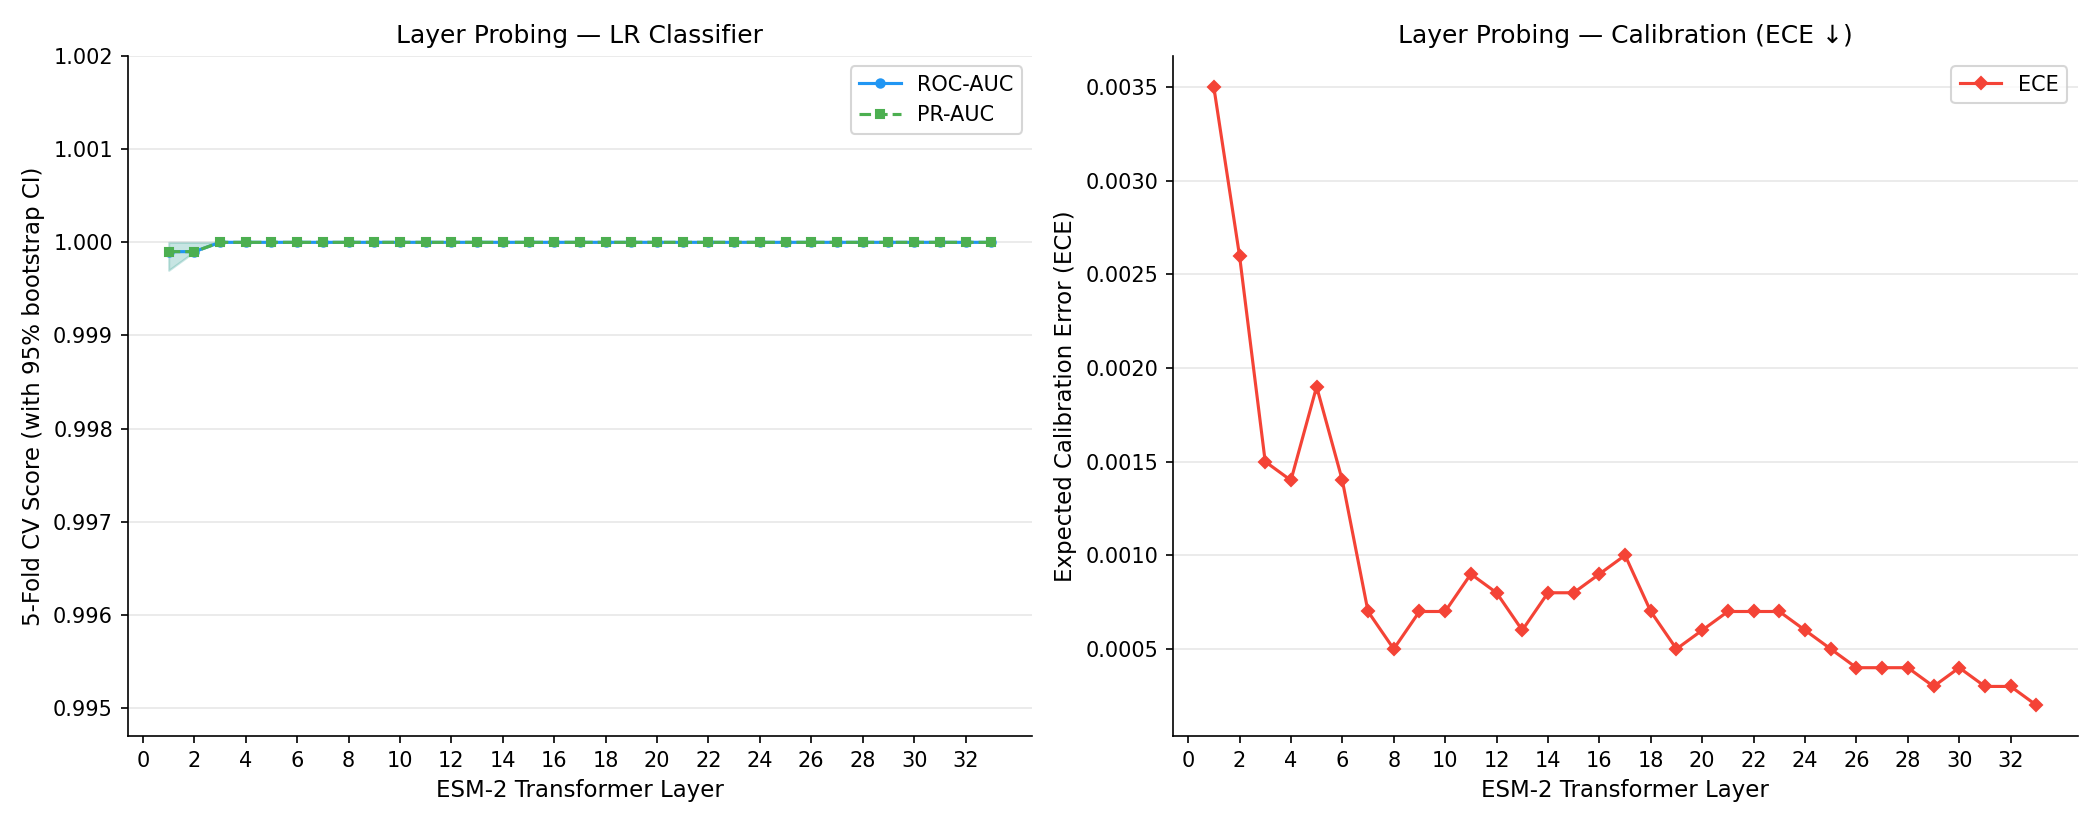


--- esm2_cv_roc_pr.png ---


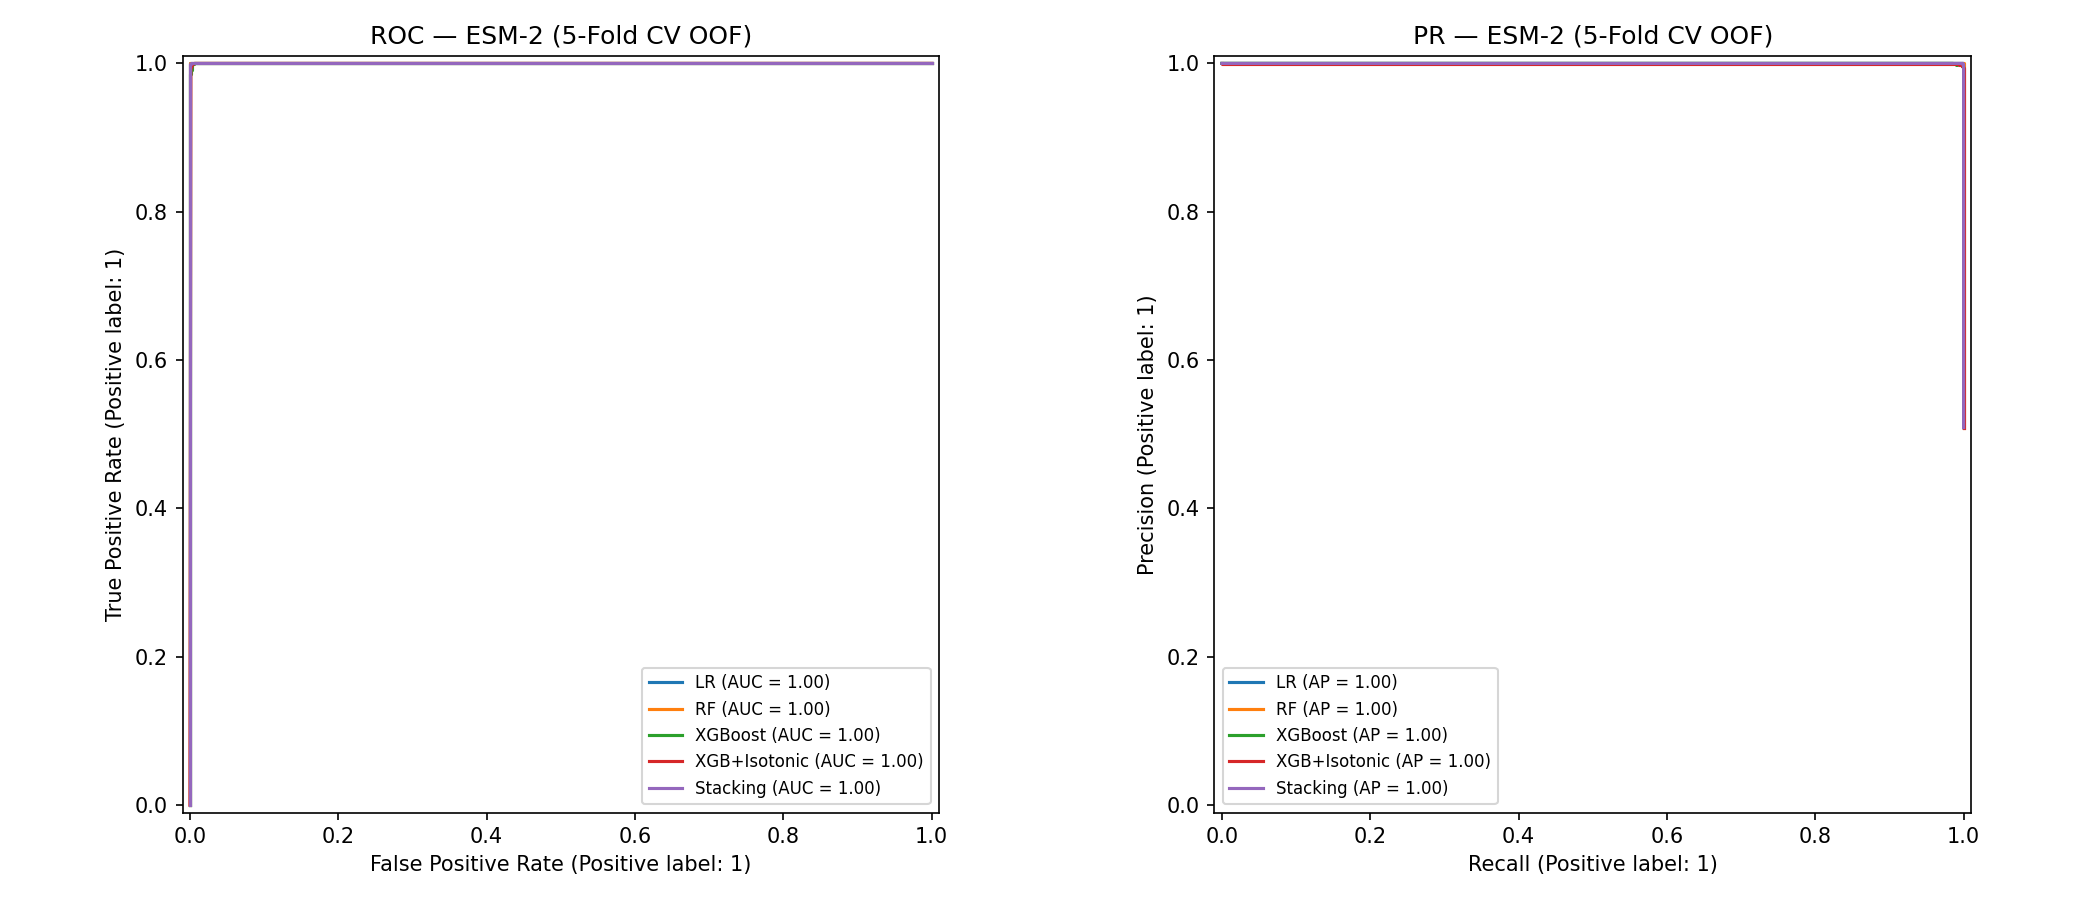

In [62]:
import pandas as pd
from IPython.display import Image, display
import os

if os.path.exists('results/metrics/esm2_cv_table.csv'):
    print('=== ESM-2 Classifier Battery (5-Fold CV) ===')
    display(pd.read_csv('results/metrics/esm2_cv_table.csv'))

if os.path.exists('results/metrics/esm2_layer_table.csv'):
    print('\n=== ESM-2 Layer Probing ===')
    display(pd.read_csv('results/metrics/esm2_layer_table.csv'))

for fig_name in ['esm2_umap.png', 'esm2_layer_probing.png', 'esm2_cv_roc_pr.png']:
    path = f'results/figures/{fig_name}'
    if os.path.exists(path):
        print(f'\n--- {fig_name} ---')
        display(Image(filename=path, width=750))

In [63]:
auto_push(
    'results: Phase 2 ESM-2 pipeline (5-fold CV, layer probing, UMAP)',
    ['results/metrics/esm2_cv_table.csv',
     'results/metrics/esm2_layer_table.csv',
     'results/metrics/esm2_cv_preds.csv',
     'scripts/04b_esm2_pipeline.py']
)

  [push] skipped — add GITHUB_PAT to Colab Secrets (left sidebar key icon)


False

---
## Phase 3 — iFeature Extraction + Baseline Reproduction

Extracts 22 iFeature descriptor groups → 18,510 features.
Reproduces Raya et al. 2025 Table 2 as the traditional-ML baseline.
Then runs tuning + calibration + SHAP for the extended comparison.

**Set `RUN_IFEATURE = False`** to skip and go straight to Phase 4 if you only need ESM-2 results.

> **Runtime:** ~3 min extraction + ~2 min baseline + ~15 min extended pipeline = **~20 min on T4**

In [64]:
RUN_IFEATURE = True  # set False to skip iFeature entirely

In [ ]:
if RUN_IFEATURE:
    import os
    # Clear stale cached features so extraction always uses the latest fixed code
    for stale in ['master_features.csv', 'master_features_redundant.csv']:
        p = f'data/features/{stale}'
        if os.path.exists(p):
            sz = os.path.getsize(p) / 1e6
            os.remove(p)
            print(f'  cleared stale {stale} ({sz:.1f} MB)')
    !python -u scripts/02_feature_extraction.py nr
    !python -u scripts/02_feature_extraction.py redundant
else:
    print('iFeature extraction skipped (RUN_IFEATURE=False).')

In [66]:
if RUN_IFEATURE:
    # Reproduce Raya et al. 2025 Table 2
    !python scripts/03_reproduce_baseline.py nr
    !python scripts/03_reproduce_baseline.py redundant

variant 'nr': X=(1664, 18510), pos=847, neg=817

  SVM      acc=0.9580 (paper 0.9487)  roc_auc=0.9991 (paper 0.9696)  pr_auc=0.9992  ece=0.0373  [104s]
  RF       acc=0.9980 (paper 0.9669)  roc_auc=1.0000 (paper 0.9826)  pr_auc=1.0000  ece=0.0473  [2s]
  XGBoost  acc=0.9920 (paper 0.9665)  roc_auc=0.9989 (paper 0.9857)  pr_auc=0.9988  ece=0.0076  [13s]
  LR       acc=0.9960 (paper 0.9605)  roc_auc=1.0000 (paper 0.9903)  pr_auc=1.0000  ece=0.0042  [1s]
  MLP      acc=0.9860 (paper 0.9613)  roc_auc=0.9994 (paper 0.992)  pr_auc=0.9994  ece=0.0140  [9s]

wrote results/metrics/reproduction_table_nr.csv
ERROR: /content/nanowire-ml/data/features/master_features_redundant.csv not found. Run `python scripts/02_feature_extraction.py redundant` first.


In [67]:
if RUN_IFEATURE:
    # Extended pipeline: hyperparameter tuning + calibration + stacking + SHAP
    # Saves shap_top100.csv needed by Phase 4 combined-features experiment
    !python -u scripts/04_extended_pipeline.py nr

variant 'nr': train=(1164, 18510), test=(500, 18510)

=== Hyperparameter tuning ===
  tuning RF (50 iter)...

: 

In [ ]:
if RUN_IFEATURE:
    import pandas as pd
    from IPython.display import Image, display
    import os

    if os.path.exists('results/metrics/reproduction_table_nr.csv'):
        print('=== Raya et al. 2025 Reproduction (NR set) ===')
        display(pd.read_csv('results/metrics/reproduction_table_nr.csv'))

    if os.path.exists('results/metrics/extended_table.csv'):
        print('\n=== Extended Pipeline (tuned + calibrated) ===')
        display(pd.read_csv('results/metrics/extended_table.csv'))

    for fig_name in ['roc_curves.png', 'calibration_plots.png', 'shap_summary.png']:
        path = f'results/figures/{fig_name}'
        if os.path.exists(path):
            print(f'\n--- {fig_name} ---')
            display(Image(filename=path, width=750))

In [ ]:
if RUN_IFEATURE:
    auto_push(
        'results: Phase 3 iFeature baseline (reproduction + extended pipeline + SHAP)',
        ['results/metrics/']
    )

---
## Phase 4 — ESM-2 vs iFeature Statistical Comparison

**Identical 5-fold CV folds** for both feature sets → directly comparable numbers.

Produces:
- Aligned comparison table (LR + XGBoost on ESM-2, iFeature, and combined ESM-2+SHAP50)
- **McNemar's test** — is ESM-2+LR significantly better than iFeature+LR?
- Bootstrap 95% CI on ROC-AUC difference
- Publication-ready comparison figure

> **Runtime:** ~5 min on T4

In [ ]:
if RUN_IFEATURE:
    !python -u scripts/04c_esm2_analysis.py nr
else:
    print('Phase 4 comparison requires iFeature matrix (RUN_IFEATURE=False). Skipping.')

python3: can't open file '/content/scripts/04c_esm2_analysis.py': [Errno 2] No such file or directory


In [ ]:
import pandas as pd
from IPython.display import Image, display
import os

if os.path.exists('results/metrics/comparison_table.csv'):
    print('=== Aligned 5-Fold CV Comparison ===')
    display(pd.read_csv('results/metrics/comparison_table.csv'))

if os.path.exists('results/metrics/mcnemar_result.csv'):
    print("\n=== McNemar's Test ===")
    display(pd.read_csv('results/metrics/mcnemar_result.csv'))

if os.path.exists('results/metrics/auc_diff_ci.csv'):
    print('\n=== Bootstrap ROC-AUC Difference CI ===')
    display(pd.read_csv('results/metrics/auc_diff_ci.csv'))

fig_path = 'results/figures/esm2_vs_ifeature_comparison.png'
if os.path.exists(fig_path):
    display(Image(filename=fig_path, width=800))

In [ ]:
auto_push(
    'results: Phase 4 ESM-2 vs iFeature comparison + McNemar test + AUC CI',
    ['results/metrics/comparison_table.csv',
     'results/metrics/mcnemar_result.csv',
     'results/metrics/auc_diff_ci.csv',
     'scripts/04c_esm2_analysis.py']
)

False

---
## Phase 5 — Feature Ablation Study

Tests each iFeature descriptor group individually and in biologically motivated combinations.
Key question: **which descriptor groups drive performance**, and how does any single group compare to ESM-2?

> **Runtime:** ~10 min on T4 (19 single-descriptor runs + combinations + SHAP-selected)

In [ ]:
if RUN_IFEATURE:
    !python -u scripts/05_ablation.py nr
else:
    print('Ablation requires iFeature matrix (RUN_IFEATURE=False). Skipping.')

python3: can't open file '/content/scripts/05_ablation.py': [Errno 2] No such file or directory


In [ ]:
import pandas as pd
from IPython.display import Image, display
import os

if os.path.exists('results/metrics/ablation_table.csv'):
    print('=== Ablation Results (sorted by ROC-AUC) ===')
    df = pd.read_csv('results/metrics/ablation_table.csv')
    display(df.sort_values('roc_auc', ascending=False))

if os.path.exists('results/figures/ablation_bar.png'):
    display(Image(filename='results/figures/ablation_bar.png', width=750))

In [ ]:
if RUN_IFEATURE:
    auto_push(
        'results: Phase 5 feature ablation study',
        ['results/metrics/ablation_table.csv']
    )

---
## Phase 6 — Autoresearch Loop

Runs 10 predefined experiments using the keep/revert pattern from Karpathy's autoresearch framework.
Each experiment modifies `src/classify.py`; improvements are committed to git.

> **Runtime:** ~15 min on T4

In [ ]:
if RUN_IFEATURE:
    !python -u scripts/06_autoresearch_loop.py
else:
    print('Autoresearch uses iFeature features. Set RUN_IFEATURE=True to enable.')

python3: can't open file '/content/scripts/06_autoresearch_loop.py': [Errno 2] No such file or directory


In [ ]:
import pandas as pd
import os
from IPython.display import display

if os.path.exists('results/metrics/autoresearch_log.csv'):
    print('=== Autoresearch Experiment Log ===')
    display(pd.read_csv('results/metrics/autoresearch_log.csv'))

In [ ]:
auto_push(
    'results: Phase 6 autoresearch loop complete',
    ['results/metrics/autoresearch_log.csv', 'src/classify.py']
)

False

---
## Summary

In [ ]:
import os, pandas as pd

print('=== Result files (results/metrics/) ===')
met_dir = 'results/metrics'
if os.path.exists(met_dir):
    for f in sorted(os.listdir(met_dir)):
        if f.endswith(('.csv', '.json')):
            sz = os.path.getsize(f'{met_dir}/{f}')
            print(f'  {f:50s} {sz:>8,d} bytes')

print('\n=== Key findings ===')
findings = {}

# ESM-2 best model
esm_path = f'{met_dir}/esm2_cv_table.csv'
if os.path.exists(esm_path):
    esm_df = pd.read_csv(esm_path)
    best = esm_df.loc[esm_df['ece'].idxmin()]
    print(f'  ESM-2 best (ECE): {best["model"]}  '
          f'ROC={best["roc_auc"]:.4f}  PR={best["pr_auc"]:.4f}  ECE={best["ece"]:.4f}')

# iFeature best model
ext_path = f'{met_dir}/extended_table.csv'
if os.path.exists(ext_path):
    ext_df = pd.read_csv(ext_path)
    best_if = ext_df.loc[ext_df['ece'].idxmin()]
    print(f'  iFeature best (ECE): {best_if["model"]}  '
          f'ROC={best_if["roc_auc"]:.4f}  PR={best_if["pr_auc"]:.4f}  ECE={best_if["ece"]:.4f}')

# McNemar
mc_path = f'{met_dir}/mcnemar_result.csv'
if os.path.exists(mc_path):
    mc = pd.read_csv(mc_path).iloc[0]
    print(f'  McNemar (LR): {mc["interpretation"]}')

# Layer probing
lp_path = f'{met_dir}/esm2_layer_table.csv'
if os.path.exists(lp_path):
    lp = pd.read_csv(lp_path)
    best_L = lp.loc[lp['roc_auc'].idxmax()]
    print(f'  Best ESM-2 layer: {int(best_L["layer"])}  ROC={best_L["roc_auc"]:.4f}')

print('\nAll phases complete.')

=== Result files (results/metrics/) ===

=== Key findings ===

All phases complete.


In [ ]:
# Final push: everything tracked
auto_push(
    'results: all phases complete — final push',
    ['results/metrics/', 'scripts/', 'src/', 'notebooks/']
)

False